In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_csv('../data/datas.csv')

dataset.head()

,carimbo_tempo,nome,data_compromisso
0,15/04/2026 13:22:56,Victor Galvão,16/04
1,15/04/2026 13:22:56,Victor Galvão,04/05
2,15/04/2026 13:22:56,Victor Galvão,08/05
3,15/04/2026 13:22:56,Victor Galvão,11/05
4,15/04/2026 13:22:56,Victor Galvão,15/05


In [39]:
#transformando a coluna de datas em datetime
dataset['data_compromisso'] = pd.to_datetime(dataset['data_compromisso'], format='%d/%m')
dataset["data_compromisso"] = dataset["data_compromisso"].apply(lambda x: x.replace(year=2026) if pd.notnull(x) else x)

dataset.tail()

,carimbo_tempo,nome,data_compromisso,mes,dia_semana,mes_nome
59,15/04/2026 21:54:34,Danielle Ribeiro,2026-07-01,7,Wednesday,Julho
268,22/04/2026 11:03:14,Hugo Toledo Martins,2026-07-02,7,Thursday,Julho
281,23/04/2026 08:43:04,Pedro Henrique de Paula Santos,2026-07-01,7,Wednesday,Julho
141,20/04/2026 11:55:43,Luisa,2026-07-01,7,Wednesday,Julho
27,15/04/2026 15:44:20,Beatriz Di Pace Gonçalves,2026-07-03,7,Friday,Julho


In [47]:
#adicionar uma coluna para mês
dataset['mes'] = dataset['data_compromisso'].dt.month
#adicionar uma coluna para dia da semana
dataset['dia_semana'] = dataset['data_compromisso'].dt.day_name()

meses_nome = {
    1: 'Janeiro',
    2: 'Fevereiro',
    3: 'Março',
    4: 'Abril',
    5: 'Maio',
    6: 'Junho',
    7: 'Julho',
    8: 'Agosto',
    9: 'Setembro',
    10: 'Outubro',
    11: 'Novembro',
    12: 'Dezembro'
}

dataset['mes_nome'] = dataset['mes'].map(meses_nome)

dataset.tail()

,carimbo_tempo,nome,data_compromisso,mes,dia_semana,mes_nome
59,15/04/2026 21:54:34,Danielle Ribeiro,2026-07-01,7,Wednesday,Julho
268,22/04/2026 11:03:14,Hugo Toledo Martins,2026-07-02,7,Thursday,Julho
281,23/04/2026 08:43:04,Pedro Henrique de Paula Santos,2026-07-01,7,Wednesday,Julho
141,20/04/2026 11:55:43,Luisa,2026-07-01,7,Wednesday,Julho
27,15/04/2026 15:44:20,Beatriz Di Pace Gonçalves,2026-07-03,7,Friday,Julho


In [42]:
#dropar domingos
dataset = dataset[dataset['dia_semana'] != 'Sunday']

dataset.head()

,carimbo_tempo,nome,data_compromisso,mes,dia_semana,mes_nome
0,15/04/2026 13:22:56,Victor Galvão,2026-04-16,4,Thursday,Abril
232,21/04/2026 19:50:33,Gabriel Henrique Oliveira,2026-04-22,4,Wednesday,Abril
28,15/04/2026 21:37:55,Ana Luisa Reis Lopes,2026-04-22,4,Wednesday,Abril
30,15/04/2026 21:37:55,Ana Luisa Reis Lopes,2026-04-25,4,Saturday,Abril
284,23/04/2026 16:55:45,Lívia,2026-04-30,4,Thursday,Abril


<Axes: xlabel='mes'>

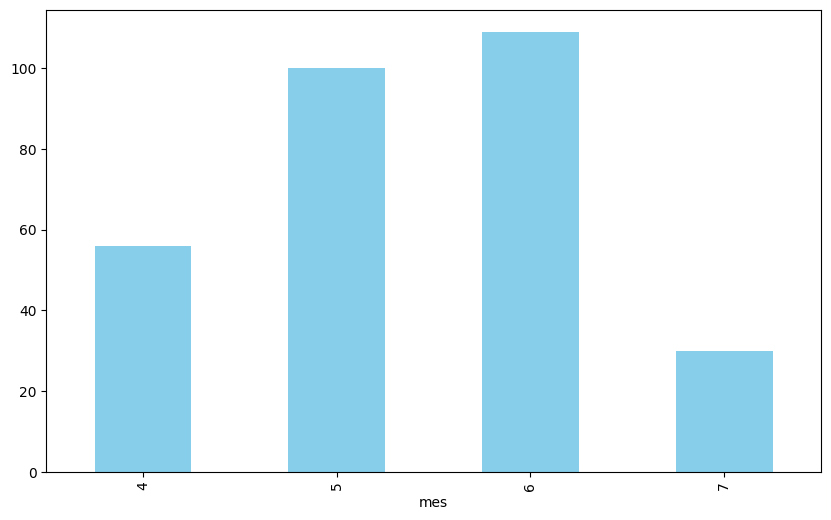

In [50]:
#analise por mes

compromissos_por_mes = dataset['mes'].value_counts()
compromissos_por_mes.sort_index(inplace=True)
plt.figure(figsize=(10, 6))
compromissos_por_mes.plot(kind='bar', color='skyblue')

Mês: Abril - Dias sem compromissos: [Timestamp('2026-04-01 00:00:00'), Timestamp('2026-04-02 00:00:00'), Timestamp('2026-04-03 00:00:00'), Timestamp('2026-04-04 00:00:00'), Timestamp('2026-04-05 00:00:00'), Timestamp('2026-04-06 00:00:00'), Timestamp('2026-04-09 00:00:00'), Timestamp('2026-04-10 00:00:00'), Timestamp('2026-04-11 00:00:00'), Timestamp('2026-04-12 00:00:00'), Timestamp('2026-04-13 00:00:00'), Timestamp('2026-04-14 00:00:00'), Timestamp('2026-04-15 00:00:00'), Timestamp('2026-04-18 00:00:00'), Timestamp('2026-04-19 00:00:00'), Timestamp('2026-04-20 00:00:00'), Timestamp('2026-04-21 00:00:00'), Timestamp('2026-04-24 00:00:00'), Timestamp('2026-04-26 00:00:00')]
Mês: Maio - Dias sem compromissos: [Timestamp('2026-05-01 00:00:00'), Timestamp('2026-05-02 00:00:00'), Timestamp('2026-05-03 00:00:00'), Timestamp('2026-05-09 00:00:00'), Timestamp('2026-05-10 00:00:00'), Timestamp('2026-05-13 00:00:00'), Timestamp('2026-05-16 00:00:00'), Timestamp('2026-05-17 00:00:00'), Timestamp

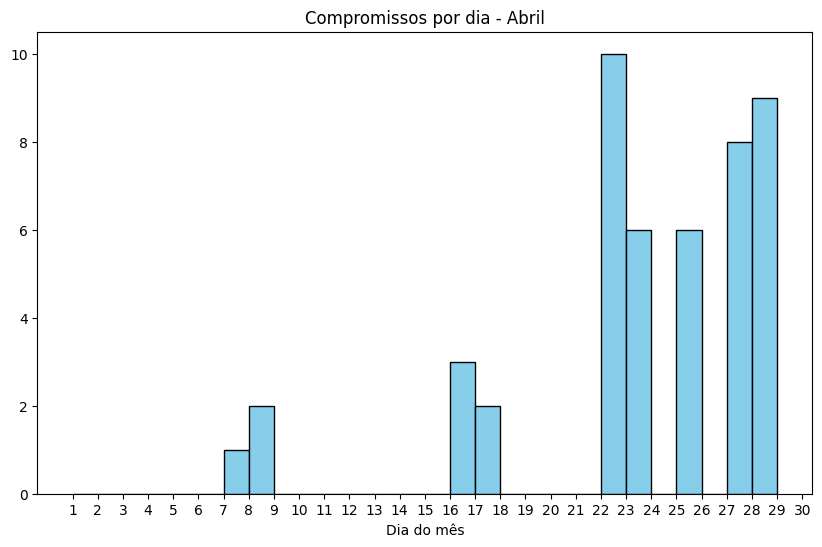

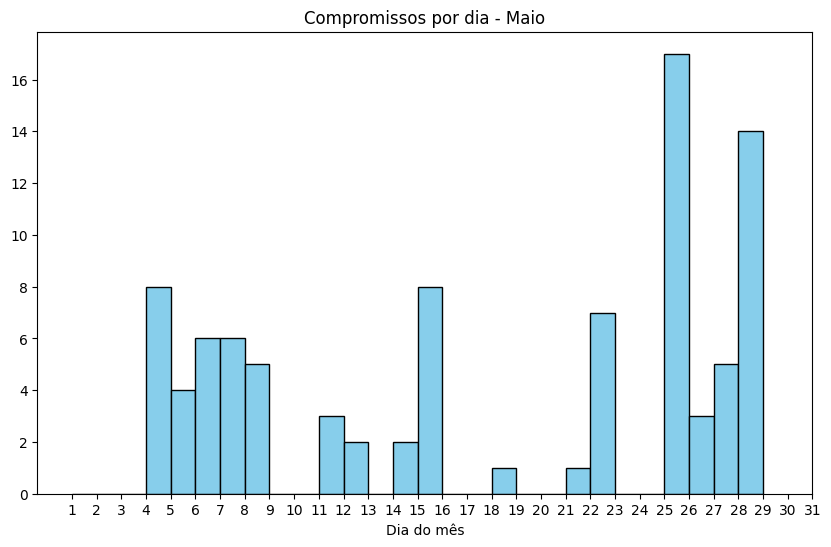

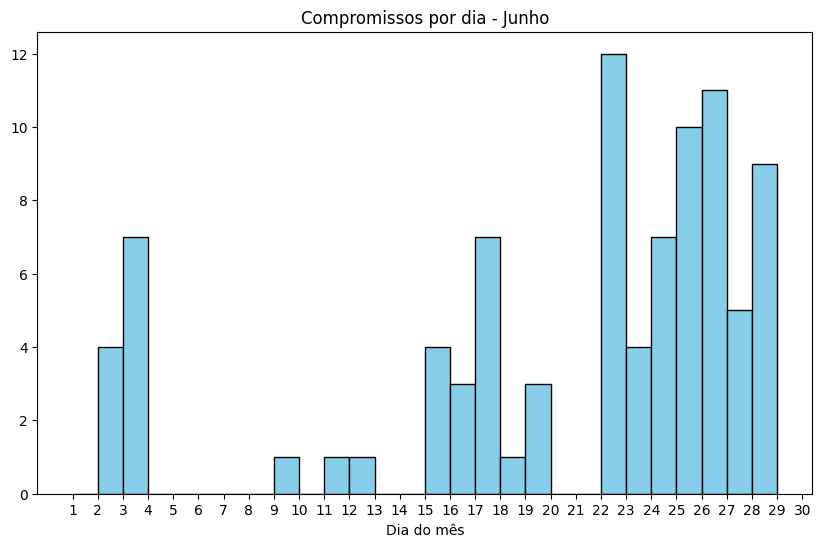

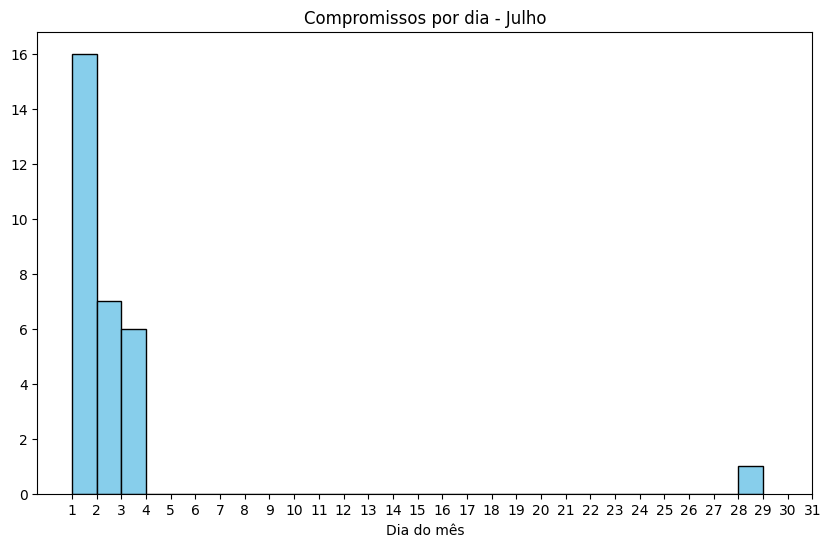

In [71]:
#verificar dias em um mes sem compromissos nos meses do dataset
for mes in dataset['mes'].unique():
    if mes == 2:
        dias_no_mes = pd.date_range(start=f'2026-{mes:02d}-01', end=f'2026-{mes:02d}-28')
    elif mes in [4, 6, 9, 11]:
        dias_no_mes = pd.date_range(start=f'2026-{mes:02d}-01', end=f'2026-{mes:02d}-30')
    else:
        dias_no_mes = pd.date_range(start=f'2026-{mes:02d}-01', end=f'2026-{mes:02d}-31')
    compromissos_no_mes = dataset[dataset['mes'] == mes]['data_compromisso']
    dias_sem_compromissos = set(dias_no_mes) - set(compromissos_no_mes)
    print(f'Mês: {meses_nome[mes]} - Dias sem compromissos: {sorted(dias_sem_compromissos)}')

    plt.figure(figsize=(10, 6))
    plt.hist(compromissos_no_mes.dt.day, bins=28, range=(1, 29), color='skyblue', edgecolor='black')
    plt.title(f'Compromissos por dia - {meses_nome[mes]}')
    if(mes == 4 or mes == 6 or mes == 9 or mes == 11):
        plt.xticks(range(1, 31))
    elif(mes == 2):
        plt.xticks(range(1, 29))
    else:
        plt.xticks(range(1, 32))
    plt.xlabel('Dia do mês')    

In [ ]:
#mostrar mdias para marcar reuniao com base nos dias sem compromissos


Dias sem compromissos para marcar reunião: [Timestamp('2026-01-01 00:00:00'), Timestamp('2026-01-02 00:00:00'), Timestamp('2026-01-03 00:00:00'), Timestamp('2026-01-04 00:00:00'), Timestamp('2026-01-05 00:00:00'), Timestamp('2026-01-06 00:00:00'), Timestamp('2026-01-07 00:00:00'), Timestamp('2026-01-08 00:00:00'), Timestamp('2026-01-09 00:00:00'), Timestamp('2026-01-10 00:00:00'), Timestamp('2026-01-11 00:00:00'), Timestamp('2026-01-12 00:00:00'), Timestamp('2026-01-13 00:00:00'), Timestamp('2026-01-14 00:00:00'), Timestamp('2026-01-15 00:00:00'), Timestamp('2026-01-16 00:00:00'), Timestamp('2026-01-17 00:00:00'), Timestamp('2026-01-18 00:00:00'), Timestamp('2026-01-19 00:00:00'), Timestamp('2026-01-20 00:00:00'), Timestamp('2026-01-21 00:00:00'), Timestamp('2026-01-22 00:00:00'), Timestamp('2026-01-23 00:00:00'), Timestamp('2026-01-24 00:00:00'), Timestamp('2026-01-25 00:00:00'), Timestamp('2026-01-26 00:00:00'), Timestamp('2026-01-27 00:00:00'), Timestamp('2026-01-28 00:00:00'), Time